In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

In [67]:
car_ins = pd.read_csv('../data/raw/car_insurance.csv')
print(car_ins[:10])

       ID    AGE  GENDER DRIVING_EXPERIENCE    EDUCATION         INCOME  \
0  569520    65+  female               0-9y  high school    upper class   
1  750365  16-25    male               0-9y         none        poverty   
2  199901  16-25  female               0-9y  high school  working class   
3  478866  16-25    male               0-9y   university  working class   
4  731664  26-39    male             10-19y         none  working class   
5  877557  40-64  female             20-29y  high school    upper class   
6  930134    65+    male               30y+  high school    upper class   
7  461006  26-39  female               0-9y   university  working class   
8   68366  40-64  female             20-29y   university  working class   
9  445911  40-64  female               0-9y  high school    upper class   

   CREDIT_SCORE  VEHICLE_OWNERSHIP  MARRIED  CHILDREN  POSTAL_CODE  \
0      0.629027                  1        0         1        10238   
1      0.357757                  0

In [68]:
car_ins.drop(['ID'], axis=1, inplace=True)

In [58]:
print(car_ins.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  10000 non-null  str    
 1   GENDER               10000 non-null  str    
 2   DRIVING_EXPERIENCE   10000 non-null  str    
 3   EDUCATION            10000 non-null  str    
 4   INCOME               10000 non-null  str    
 5   CREDIT_SCORE         9018 non-null   float64
 6   VEHICLE_OWNERSHIP    10000 non-null  int64  
 7   MARRIED              10000 non-null  int64  
 8   CHILDREN             10000 non-null  int64  
 9   POSTAL_CODE          10000 non-null  int64  
 10  ANNUAL_MILEAGE       9043 non-null   float64
 11  VEHICLE_TYPE         10000 non-null  str    
 12  SPEEDING_VIOLATIONS  10000 non-null  int64  
 13  DUIS                 10000 non-null  int64  
 14  PAST_ACCIDENTS       10000 non-null  int64  
 15  OUTCOME              10000 non-null  int64  
dty

In [88]:
thing = car_ins[['INCOME','CREDIT_SCORE', 'ANNUAL_MILEAGE']].groupby('INCOME').mean()
print(thing)
for x in car_ins['INCOME'].unique():
    car_ins[car_ins['INCOME']==x] = car_ins[car_ins['INCOME']==x].fillna(value = {'CREDIT_SCORE':thing.loc[x, 'CREDIT_SCORE'], 'ANNUAL_MILEAGE':thing.loc[x, 'ANNUAL_MILEAGE']})
print(car_ins.info())

               CREDIT_SCORE  ANNUAL_MILEAGE
INCOME                                     
middle class       0.523659    11829.433177
poverty            0.348331    12824.938575
upper class        0.613827    10921.692854
working class      0.431929    12323.415265
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  10000 non-null  str    
 1   GENDER               10000 non-null  str    
 2   DRIVING_EXPERIENCE   10000 non-null  str    
 3   EDUCATION            10000 non-null  str    
 4   INCOME               10000 non-null  str    
 5   CREDIT_SCORE         10000 non-null  float64
 6   VEHICLE_OWNERSHIP    10000 non-null  int64  
 7   MARRIED              10000 non-null  int64  
 8   CHILDREN             10000 non-null  int64  
 9   POSTAL_CODE          10000 non-null  int64  
 10  ANNUAL_MILEAGE       10000 non-nul

In [89]:
print(car_ins['DRIVING_EXPERIENCE'].unique())

<StringArray>
['0-9y', '10-19y', '20-29y', '30y+']
Length: 4, dtype: str


AGE                '16-25' '26-39' '40-64' '65+'                          OrdinalEncoder
GENDER             'female' 'male'                                        LabelEncoder
DRIVING_EXPERIENCE '0-9y' '10-19y' '20-29y' '30y+'                         OrdinalEncoder
EDUCATION          'none' 'high school' 'university'                      OrdinalEncoder
INCOME             'poverty' 'working class' 'middle class' 'upper class' OrdinalEncoder
VEHICLE_TYPE       'sedan' 'sports car'                                   OneHotEncoder

In [90]:
cop = car_ins.copy()
label_encoder = LabelEncoder()
cop['GENDER'] = label_encoder.fit_transform(cop['GENDER'])

onehot_encoder = OneHotEncoder()
cop[['SEDAN', 'SPORTS_CAR']] = onehot_encoder.fit_transform(cop[['VEHICLE_TYPE']]).toarray()

age_encoder = OrdinalEncoder(categories=[['16-25', '26-39', '40-64', '65+']])
exp_encoder = OrdinalEncoder(categories=[['0-9y', '10-19y', '20-29y', '30y+']])
edu_encoder = OrdinalEncoder(categories=[['none', 'high school', 'university']])
income_encoder = OrdinalEncoder(categories=[['poverty', 'working class', 'middle class', 'upper class']])
cop['AGE'] = age_encoder.fit_transform(cop[['AGE']])
cop['DRIVING_EXPERIENCE'] = exp_encoder.fit_transform(cop[['DRIVING_EXPERIENCE']])
cop['EDUCATION'] = edu_encoder.fit_transform(cop[['EDUCATION']])
cop['INCOME'] = income_encoder.fit_transform(cop[['INCOME']])

print(cop)

      AGE  GENDER  DRIVING_EXPERIENCE  EDUCATION  INCOME  CREDIT_SCORE  \
0     3.0       0                 0.0        1.0     3.0      0.629027   
1     0.0       1                 0.0        0.0     0.0      0.357757   
2     0.0       0                 0.0        1.0     1.0      0.493146   
3     0.0       1                 0.0        2.0     1.0      0.206013   
4     1.0       1                 1.0        0.0     1.0      0.388366   
...   ...     ...                 ...        ...     ...           ...   
9995  1.0       0                 1.0        2.0     3.0      0.582787   
9996  1.0       0                 1.0        0.0     2.0      0.522231   
9997  1.0       1                 0.0        1.0     2.0      0.470940   
9998  1.0       0                 1.0        1.0     0.0      0.364185   
9999  1.0       0                 0.0        0.0     1.0      0.435225   

      VEHICLE_OWNERSHIP  MARRIED  CHILDREN  POSTAL_CODE  ANNUAL_MILEAGE  \
0                     1        0    

In [91]:
car_ins_encoded = cop

<Axes: >

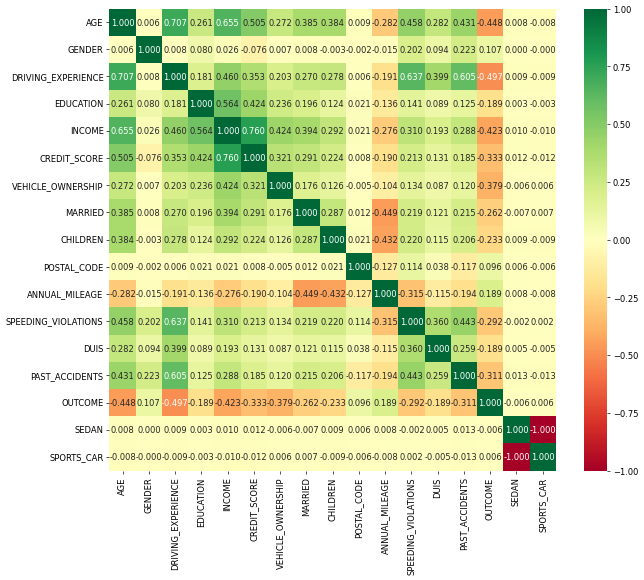

In [92]:
plt.figure(figsize=(12, 10), dpi=60)
df1 = car_ins_encoded.copy()
df1_n = df1.select_dtypes(['number'])
df1_corr = df1_n.corr()
sns.heatmap(df1_corr, xticklabels=df1_corr.columns, yticklabels=df1_corr.columns, annot=True, fmt='.3f', cmap='RdYlGn')

In [93]:
car_ins_encoded.to_csv('../data/processed/car_insurance.csv')